In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../../..'))
from src.models.v3.n_gram_network import Tokenizer, NGramNetwork
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

In [2]:
# Hyperparameters

context_size = 3
embedding_vector_size = 8
#w1_out = 256
batch_size = 64
iterations = 10_000

lr_slope = 1/10_000
lr_max = 1
lr_min = 0.001


def learning_rate_function(i:float) -> float:
    lr = lr_max - i * lr_slope
    if lr < lr_min:
        return lr_min
    return lr

In [3]:
# Initializations for network

data_path = '../../../src/data/normalized/en_cities.txt'
tokenizer = Tokenizer(data_path)

In [4]:
def test_w1_out_hyperparam(w1_out: int) -> float:
    # Init and train network
    network = NGramNetwork(context_size, tokenizer, data_path, embedding_vector_size, w1_out)
    network.train(batch_size, iterations, learning_rate_function, print_out=False, use_dev_set=True)
    
    # Return test set loss
    return network.evaluate_test_set()
    
    

In [5]:
# Test w1_outs from 8 to 512:
w1s = []
losses = []
times = []

for w1_out in range(8, 500, 16):
    start_time = time.perf_counter()
    
    loss = test_w1_out_hyperparam(w1_out)

    elapsed_time = time.perf_counter() - start_time
    
    w1s.append(w1_out)
    losses.append(loss)
    times.append(elapsed_time)
    
    print(w1_out, '-->', loss)

8 --> 2.5524728298187256
24 --> 2.55104923248291
40 --> 2.630563259124756
56 --> 2.8502113819122314
72 --> 2.9063265323638916
88 --> 3.09035062789917
104 --> 3.2635397911071777
120 --> 3.5316238403320312
136 --> 3.5685181617736816
152 --> 3.8071718215942383
168 --> 3.8533108234405518
184 --> 3.9298202991485596
200 --> 4.040866851806641
216 --> 4.126789569854736
232 --> 4.217325210571289
248 --> 4.3616132736206055
264 --> 4.4906768798828125
280 --> 4.520343780517578
296 --> 4.673089027404785
312 --> 4.6493821144104
328 --> 4.904552459716797
344 --> 4.898839950561523
360 --> 5.119942665100098
376 --> 5.147765636444092
392 --> 5.259328842163086
408 --> 5.279966354370117
424 --> 5.537271022796631
440 --> 5.590465068817139
456 --> 5.517099857330322
472 --> 5.697153091430664
488 --> 5.79833459854126


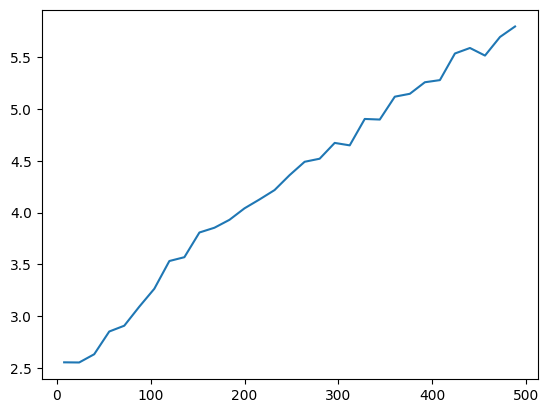

In [6]:
plt.plot(w1s, losses)
plt.show()

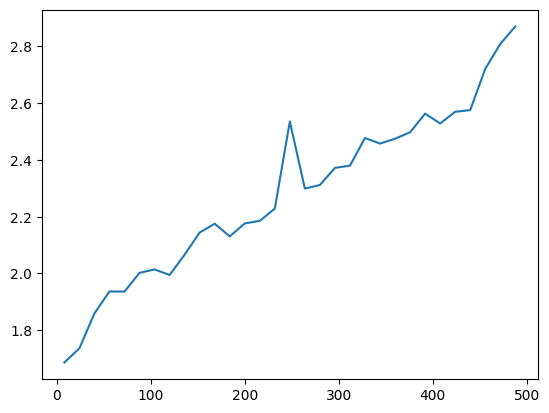

In [7]:
plt.plot(w1s, times)
plt.show()

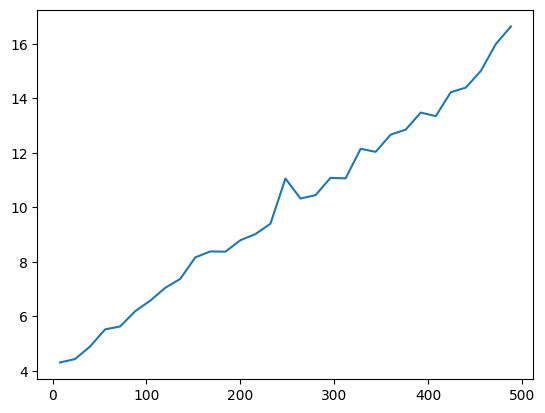

In [8]:
plt.plot(w1s, np.array(losses) * np.array(times))
plt.show()